In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_1samp, shapiro, levene, ttest_ind, mannwhitneyu, \
    pearsonr, spearmanr, kendalltau, f_oneway, kruskal, permutation_test
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.multicomp import MultiComparison
from ydata_profiling import ProfileReport

%matplotlib inline
sns.set_style('darkgrid')

In [2]:
df = pd.read_csv('C:/Python/Datasets/four_sessions.csv')

In [3]:
ProfileReport(df, title="Profiling Report")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:00<00:00, 47.49it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [4]:
sns.set_style('darkgrid')

<Axes: xlabel='Time'>

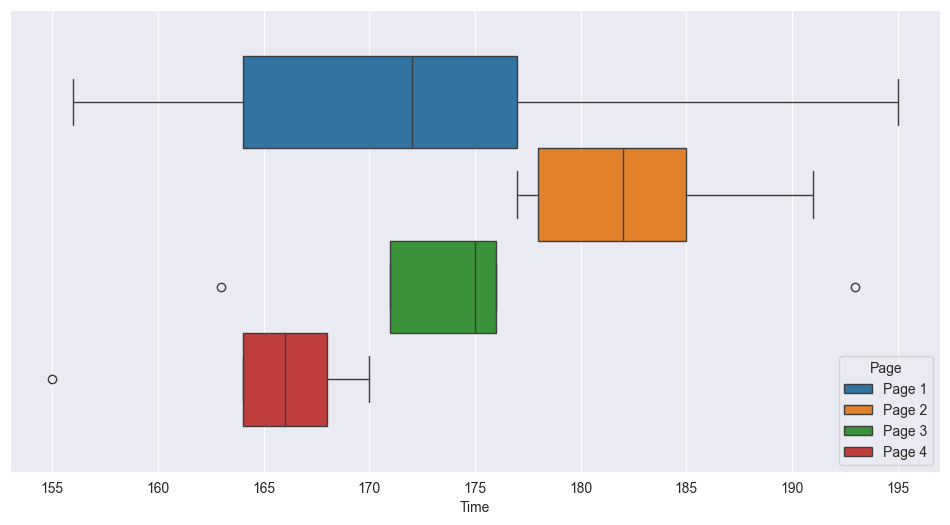

In [5]:
plt.subplots(figsize=(12,6))
sns.boxplot(data=df, x='Time', hue='Page')

For permutatuon test:
1. Compute the variance

In [6]:
df.groupby("Page")["Time"].mean()

Page
Page 1    172.8
Page 2    182.6
Page 3    175.6
Page 4    164.6
Name: Time, dtype: float64

In [7]:
real_var = df.groupby("Page")["Time"].mean().var()
real_var

np.float64(55.426666666666655)

2. Create a copy of dataset for the permutation

In [8]:
df_perm = df.copy()

In [9]:
df_perm.groupby("Page")["Time"].mean().var()

np.float64(55.426666666666655)

3. Do the permutation and compute variances

In [10]:
# Фиксируем случайность для воспроизводимости
np.random.seed(42)

# --- 1. Вычисляем наблюдаемую статистику на реальных данных ---
real_var = df_perm.groupby("Page")["Time"].mean().var()

# --- 2. Создаём список для нулевого распределения ---
variances_null = []

# --- 3. Перестановочный тест: 10 000 итераций ---
for i in range(10_000):
    # Перемешиваем значения времени
    df_perm["Time"] = np.random.permutation(df_perm["Time"])
    
    # Вычисляем дисперсию средних после перемешивания
    null_var = df_perm.groupby("Page")["Time"].mean().var()
    variances_null.append(null_var)

# --- 4. Расчёт p-value (двусторонний) ---
# Для двустороннего теста считаем долю перестановок, где статистика >= наблюдаемой
# (так как дисперсия всегда неотрицательна, и нас интересуют любые отклонения вверх)
p_value = np.mean(np.array(variances_null) >= real_var)

# --- 5. Вывод результатов ---
print(f"Наблюдаемая дисперсия средних: {real_var:.4f}")
print(f"Среднее нулевое распределение: {np.mean(variances_null):.4f}")
print(f"p-value: {p_value:.4f}")

# Двусторонний p-value по методу SciPy
p_greater = np.mean(np.array(variances_null) >= real_var)
p_less = np.mean(np.array(variances_null) <= real_var)
p_two_sided = 2 * min(p_greater, p_less)
print(f"Двухсторонний p-value: {p_two_sided:.4f}")

Наблюдаемая дисперсия средних: 55.4267
Среднее нулевое распределение: 25.7353
p-value: 0.0803
Двухсторонний p-value: 0.1606


p_value > 0.05 so no statistical significance

also can be performed in scipy

In [11]:
df_perm_scipy = df.copy()

In [12]:
def variance_of_means(*samples, axis=0):
    """
    Вычисляет дисперсию средних значений для нескольких выборок.

    Параметры:
    *samples: массивы данных для каждой группы.
    axis: ось, вдоль которой вычисляются средние (для векторизации).

    Возвращает:
    Дисперсию средних значений групп.
    """
    # Вычисляем среднее для каждой выборки
    means = np.array([np.mean(sample, axis=axis) for sample in samples])
    # Возвращаем дисперсию этих средних
    return np.var(means)

In [13]:
result = permutation_test(
    data=(df_perm_scipy.loc[df_perm_scipy.Page == 'Page 1', 'Time'].values,
          df_perm_scipy.loc[df_perm_scipy.Page == 'Page 2', 'Time'].values,
          df_perm_scipy.loc[df_perm_scipy.Page == 'Page 3', 'Time'].values,
          df_perm_scipy.loc[df_perm_scipy.Page == 'Page 4', 'Time'].values),  # Передаём все группы
    statistic=variance_of_means,    # Наша функция статистики
    permutation_type='independent', # Для независимых выборок (значение по умолчанию)
    vectorized=False,               # <- ключевой параметр
    n_resamples=10_000,              # Количество перестановок
    random_state=42                 # Для воспроизводимости
)

print(f"Наблюдаемая дисперсия средних: {result.statistic:.4f}")
print(f"p-value: {result.pvalue:.4f}")

Наблюдаемая дисперсия средних: 41.5700
p-value: 0.1560


p_value > 0.05 so no statistical significance

<Axes: xlabel='Time', ylabel='Density'>

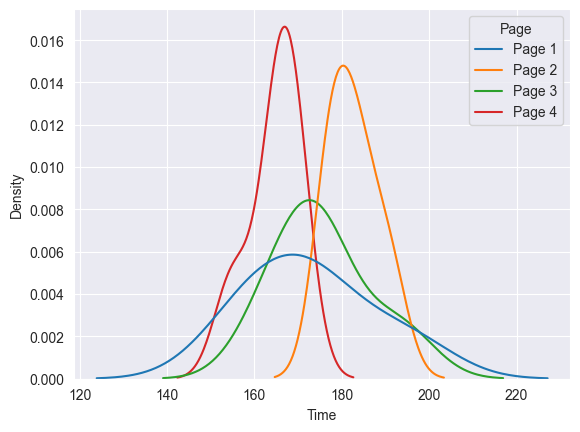

In [14]:
sns.kdeplot(data=df, x='Time', hue='Page')

Also test with anova

Shapiro-Wilk for normal distribution

In [15]:
for group in list(df["Page"].unique()):
    pvalue = shapiro(df.loc[df["Page"] == group, "Time"])[1]
    print(group, 'p-value: %.4f' % pvalue)

Page 1 p-value: 0.8732
Page 2 p-value: 0.6350
Page 3 p-value: 0.5653
Page 4 p-value: 0.3299


Normal distribution is met

Levene test for homogenity

In [16]:
test_stat, pvalue = levene(df.loc[df['Page'] == 'Page 1', "Time"],
                           df.loc[df['Page'] == 'Page 2', "Time"],
                           df.loc[df['Page'] == 'Page 3', "Time"],
                           df.loc[df['Page'] == 'Page 4', 'Time'])
print('Test Stat = %.4f, p-value = %.4f' % (test_stat, pvalue))

Test Stat = 1.0821, p-value = 0.3849


Homogenity is met

do classical anova

In [17]:
f_oneway(df.loc[df['Page'] == 'Page 1', "Time"],
        df.loc[df['Page'] == 'Page 2', "Time"],
        df.loc[df['Page'] == 'Page 3', "Time"],
        df.loc[df['Page'] == 'Page 4', 'Time'])

F_onewayResult(statistic=np.float64(2.739825341901467), pvalue=np.float64(0.07758621525801461))

pvalue > 0.05 so no statistical significance

also try tukey (not necessary as there is no statistical significance in f_oneway)

In [18]:
comparison = MultiComparison(df['Time'], # сначала метрика
                            df['Page'])  # потом группа
tukey = comparison.tukeyhsd(0.05)
tukey.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
Page 1,Page 2,9.8,0.4379,-8.3984,27.9984,False
Page 1,Page 3,2.8,0.9706,-15.3984,20.9984,False
Page 1,Page 4,-8.2,0.5825,-26.3984,9.9984,False
Page 2,Page 3,-7.0,0.6943,-25.1984,11.1984,False
Page 2,Page 4,-18.0,0.0531,-36.1984,0.1984,False
Page 3,Page 4,-11.0,0.3416,-29.1984,7.1984,False
